# Sea Ice Concentration On Projected Grids

Create CMIP7 monthly sea-ice area percentage files (`siconc_tavg-u-hxy-u`) using the Northern and Southern Hemisphere EASE2 Lambert azimuthal equal-area grids from the NetCDF files in `data/`.

In [1]:
from pathlib import Path
import json
import os
import shutil

os.environ.setdefault("MPLCONFIGDIR", str((Path("output") / ".matplotlib").resolve()))
os.environ.setdefault("XDG_CACHE_HOME", str((Path("output") / ".cache").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import cmor
from IPython.display import display
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import pyproj
import xarray as xr

TABLES_DIR = "../cmip7-cmor-tables/tables"
CV_PATH = "../cmip7-cmor-tables/tables-cvs/cmor-cvs.json"
DATA_PATHS = {
    "nh": Path("data") / "ice_conc_nh_ease2-250_cdr-v3p1_202002.nc",
    "sh": Path("data") / "ice_conc_sh_ease2-250_cdr-v3p1_202002.nc",
}
if not Path(TABLES_DIR).exists():
    raise FileNotFoundError(f"CMIP7 tables directory not found: {TABLES_DIR}")
if not Path(CV_PATH).exists():
    raise FileNotFoundError(f"CMIP7 CV file not found: {CV_PATH}")
for data_path in DATA_PATHS.values():
    if not data_path.exists():
        raise FileNotFoundError(f"Source data file not found: {data_path}")

print(f"Using CMIP7 tables from {TABLES_DIR}")

Using CMIP7 tables from ../cmip7-cmor-tables/tables


In [2]:
with xr.open_dataset(DATA_PATHS["nh"], decode_times=False) as opened:
    north_source = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=90,
):
    display(north_source)

<xarray.Dataset> Size: 5MB
Dimensions:                 (time: 1, yc: 432, xc: 432, nv: 2)
Coordinates:
  * time                    (time) float64 8B 1.329e+09
  * yc                      (yc) float64 3kB 5.388e+03 5.362e+03 ... -5.388e+03
  * xc                      (xc) float64 3kB -5.388e+03 -5.362e+03 ... 5.388e+03
    lat                     (yc, xc) float32 746kB 16.62 16.82 ... 16.82 16.62
    lon                     (yc, xc) float32 746kB -135.0 -135.1 ... 44.87 45.0
Dimensions without coordinates: nv
Data variables:
    Lambert_Azimuthal_Grid  int32 4B -2147483647
    ice_conc                (time, yc, xc) float64 1MB 0.0 0.0 0.0 ... nan nan
    raw_ice_conc_values     (time, yc, xc) float64 1MB nan nan nan ... nan nan
    status_flag             (time, yc, xc) float32 746kB 128.0 128.0 ... 1.0 1.0
    time_bnds               (time, nv) float64 16B 1.328e+09 1.331e+09
Attributes:
    title:                     Monthly Sea Ice Concentration Climate Data Rec...
    summary:                   This climate data record of sea ice concentrat...
    topiccategory:             Oceans ClimatologyMeteorologyAtmosphere
    geospatial_lat_min:        16.62393
    geospatial_lat_max:        90.0
    geospatial_lon_min:        -180.0
    geospatial_lon_max:        180.0
    geospatial_vertical_min:   0.0
    geospatial_vertical_max:   0.0
    sensor:                    SMMR,SSM/I,SSMIS
    platform:                  Nimbus-7,DMSP-F<08,10,11,13,14,15>,DMSP-F<16,1...
    time_coverage_start:       2020-02-01T00:00:00Z
    time_coverage_end:         2020-03-01T00:00:00Z
    time_coverage_duration:    P1M
    time_coverage_resolution:  P1M
    project:                   OSI SAF - EUMETSAT
    institution:               OSISAF - EUMETSAT
    creator_name:              OSISAF - EUMETSAT
    creator_type:              institution
    creator_url:               https://osi-saf.eumetsat.int/
    creator_email:             osi-saf.helpdesk@meteo.fr
    date_created:              2023-03-20
    cdm_data_type:             Grid
    spatial_resolution:        25.0 km grid spacing
    geospatial_bounds_crs:     EPSG:6931
    tracking_id:               537df889-640b-44f8-bb9f-f49d9b281ca1
    naming_authority:          int.eumetsat
    standard_name_vocabulary:  CF Standard Name Table (Version 78, 21 Septemb...
    product_name:              osi_saf_sea_ice_conc_climate_data_record_smmrs...
    keywords:                  GCMDSK:Earth Science > Cryosphere > Sea Ice > ...
    keywords_vocabulary:       GCMDSK:GCMD Science Keywords:https://gcmd.eart...
    Conventions:               CF-1.7,ACDD-1.3
    algorithm:                 SICCI3LF (19V, 37V, 37H)
    contributor_name:          Thomas Lavergne,Atle Soerensen,Rasmus Tonboe,C...
    contributor_role:          PrincipalInvestigator,author,author,author,aut...
    source:                    FCDR of SMMR / SSMI / SSMIS Brightness Tempera...
    product_status:            released
    history:                   2023-03-20T13:57:20Z creation\n2025-02-17T11:0...
    product_version:           3.1
    product_id:                osi-450-a1
    doi:                       10.15770/EUM_SAF_OSI_0023
    references:                Product User Manual (2025),Algorithm Theoretic...
    license:                   http://creativecommons.org/licenses/by/4.0/

In [3]:
run_dir = Path("output") / "06_non_lat_lon_sea_ice_concentration"
if run_dir.exists():
    shutil.rmtree(run_dir)
output_dir = run_dir / "cmor_output"
output_dir.mkdir(parents=True)

DATASET_INFO_BASE = {
    "_AXIS_ENTRY_FILE": "CMIP7_coordinate.json",
    "_FORMULA_VAR_FILE": "CMIP7_formula_terms.json",
    "_cmip7_option": 1,
    "_controlled_vocabulary_file": CV_PATH,
    "activity_id": "CMIP",
    "calendar": "standard",
    "experiment_id": "amip",
    "forcing_index": "f3",
    "frequency": "mon",
    "grid_label": "g999",
    "host_collection": "CMIP7",
    "initialization_index": "i1",
    "institution_id": "CCCma",
    "license_id": "CC-BY-4.0",
    "nominal_resolution": "25 km",
    "physics_index": "p1",
    "realization_index": "r9",
    "source_id": "DUMMY-MODEL",
}


def cell_edges(values):
    return np.concatenate(
        ([values[0] - 0.5 * (values[1] - values[0])], 0.5 * (values[:-1] + values[1:]), [values[-1] + 0.5 * (values[-1] - values[-2])])
    )


def prepare_ease2_source(data_path):
    with xr.open_dataset(data_path, decode_times=False) as opened:
        source = opened.load()

    x = (source["xc"].values * 1000.0).astype("f8")
    y = (source["yc"].values[::-1] * 1000.0).astype("f8")
    latitude = source["lat"].values[::-1, :].T.astype("f8")
    longitude = (source["lon"].values[::-1, :].T % 360.0).astype("f8")

    missing_value = np.float32(1.0e20)
    ice_conc = source["ice_conc"].isel(time=0).values[::-1, :].T.astype("f4")
    siconc = np.where(np.isfinite(ice_conc), ice_conc, missing_value).astype("f4")[None, :, :]

    x_edges = cell_edges(x)
    y_edges = cell_edges(y)
    mapping_attrs = source["Lambert_Azimuthal_Grid"].attrs
    source_crs = pyproj.CRS.from_proj4(mapping_attrs["proj4_string"])
    transformer = pyproj.Transformer.from_crs(source_crs, source_crs.geodetic_crs, always_xy=True)
    latitude_vertices = np.empty((*latitude.shape, 4), dtype="f8")
    longitude_vertices = np.empty((*longitude.shape, 4), dtype="f8")
    for vertex, (x_vertex, y_vertex) in enumerate(
        [
            (x_edges[:-1][:, None], y_edges[:-1][None, :]),
            (x_edges[1:][:, None], y_edges[:-1][None, :]),
            (x_edges[1:][:, None], y_edges[1:][None, :]),
            (x_edges[:-1][:, None], y_edges[1:][None, :]),
        ]
    ):
        lon_vertex, lat_vertex = transformer.transform(x_vertex, y_vertex)
        latitude_vertices[:, :, vertex] = lat_vertex
        longitude_vertices[:, :, vertex] = lon_vertex % 360.0

    crs_params = {
        "latitude_of_projection_origin": [float(mapping_attrs["latitude_of_projection_origin"]), "degrees_north"],
        "longitude_of_projection_origin": [float(mapping_attrs["longitude_of_projection_origin"]), "degrees_east"],
        "false_easting": [float(mapping_attrs["false_easting"]), "m"],
        "false_northing": [float(mapping_attrs["false_northing"]), "m"],
        "semi_major_axis": [float(mapping_attrs["semi_major_axis"]), "m"],
        "inverse_flattening": [float(mapping_attrs["inverse_flattening"]), ""],
    }

    return {
        "x": x,
        "y": y,
        "latitude": latitude,
        "longitude": longitude,
        "latitude_vertices": latitude_vertices,
        "longitude_vertices": longitude_vertices,
        "siconc": siconc,
        "missing_value": missing_value,
        "time": source["time"].values.astype("f8"),
        "time_bnds": source["time_bnds"].values.astype("f8").reshape(2),
        "time_units": source["time"].attrs["units"],
        "crs_params": crs_params,
    }


prepared_sources = {region: prepare_ease2_source(data_path) for region, data_path in DATA_PATHS.items()}
for region, prepared in prepared_sources.items():
    print(region, prepared["siconc"].shape, prepared["latitude"].shape, prepared["latitude_vertices"].shape)

nh (1, 432, 432) (432, 432) (432, 432, 4)
sh (1, 432, 432) (432, 432) (432, 432, 4)


In [4]:
def table_lookup(table_name, section_name, compound_name):
    with open(Path(TABLES_DIR) / table_name) as handle:
        return json.load(handle)[section_name].get(compound_name)


def write_cmor_siconc(region, prepared):
    dataset_info = dict(DATASET_INFO_BASE)
    dataset_info.update({"outpath": str(output_dir), "region": region})
    input_json = run_dir / f"input_{region}.json"
    input_json.write_text(json.dumps(dataset_info, indent=2, sort_keys=True))

    cmor.setup(
        inpath=TABLES_DIR,
        netcdf_file_action=cmor.CMOR_REPLACE,
        logfile=str(run_dir / f"cmor_{region}.log"),
    )
    cmor.dataset_json(str(input_json))

    grid_table = cmor.load_table("CMIP7_grids.json")
    seaice_table = cmor.load_table("CMIP7_seaIce.json")

    cmor.set_table(grid_table)
    x_id = cmor.axis("x", coord_vals=prepared["x"], units="m")
    y_id = cmor.axis("y", coord_vals=prepared["y"], units="m")
    grid_id = cmor.grid(
        axis_ids=[x_id, y_id],
        latitude=prepared["latitude"],
        longitude=prepared["longitude"],
        latitude_vertices=prepared["latitude_vertices"],
        longitude_vertices=prepared["longitude_vertices"],
    )
    cmor.set_crs(grid_id, "lambert_azimuthal_equal_area", prepared["crs_params"])

    cmor.set_table(seaice_table)
    time_id = cmor.axis("time", coord_vals=prepared["time"], cell_bounds=prepared["time_bnds"], units=prepared["time_units"])

    variable_name = "siconc_tavg-u-hxy-u"
    siconc_id = cmor.variable(variable_name, "%", [time_id, grid_id], missing_value=prepared["missing_value"])
    compound_name = ".".join(["seaIce"] + variable_name.split("_") + ["mon", region])

    cell_measure = table_lookup("CMIP7_cell_measures.json", "cell_measures", compound_name)
    if cell_measure:
        cmor.set_variable_attribute(siconc_id, "cell_measures", "c", cell_measure)

    long_name = table_lookup("CMIP7_long_name_overrides.json", "long_name_overrides", compound_name)
    if long_name:
        cmor.set_variable_attribute(siconc_id, "long_name", "c", long_name)

    cmor.write(siconc_id, prepared["siconc"])
    netcdf_path = Path(cmor.close(siconc_id, file_name=True))
    cmor.close()
    return netcdf_path


netcdf_paths = {region: write_cmor_siconc(region, prepared) for region, prepared in prepared_sources.items()}
for region, netcdf_path in netcdf_paths.items():
    print(region, netcdf_path.resolve().relative_to(Path.cwd().resolve()))

nh output/06_non_lat_lon_sea_ice_concentration/cmor_output/MIP-DRS7/CMIP7/CMIP/CCCma/DUMMY-MODEL/amip/r9i1p1f3/nh/mon/siconc/tavg-u-hxy-u/g999/v20260529/siconc_tavg-u-hxy-u_mon_nh_g999_DUMMY-MODEL_amip_r9i1p1f3_202002-202002.nc
sh output/06_non_lat_lon_sea_ice_concentration/cmor_output/MIP-DRS7/CMIP7/CMIP/CCCma/DUMMY-MODEL/amip/r9i1p1f3/sh/mon/siconc/tavg-u-hxy-u/g999/v20260529/siconc_tavg-u-hxy-u_mon_sh_g999_DUMMY-MODEL_amip_r9i1p1f3_202002-202002.nc


In [5]:
with xr.open_dataset(netcdf_paths["nh"], decode_times=False) as opened:
    ds = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=90,
):
    display(ds)

<xarray.Dataset> Size: 16MB
Dimensions:             (time: 1, bnds: 2, x: 432, y: 432, vertices: 4)
Coordinates:
  * time                (time) float64 8B 1.539e+04
  * x                   (x) float64 3kB -5.388e+06 -5.362e+06 ... 5.388e+06
  * y                   (y) float64 3kB -5.388e+06 -5.362e+06 ... 5.388e+06
    latitude            (x, y) float64 1MB 16.62 16.82 17.02 ... 16.82 16.62
    longitude           (x, y) float64 1MB 315.0 314.9 314.7 ... 134.9 135.0
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) float64 16B 1.537e+04 1.54e+04
    crs                 int32 4B -2147483647
    vertices_latitude   (x, y, vertices) float64 6MB 16.42 16.62 ... 16.42 16.62
    vertices_longitude  (x, y, vertices) float64 6MB 315.0 315.1 ... 135.0 135.1
    siconc              (time, x, y) float32 746kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    Conventions:           CF-1.12
    activity_id:           CMIP
    area_label:            u
    branded_variable:      siconc_tavg-u-hxy-u
    branding_suffix:       tavg-u-hxy-u
    creation_date:         2026-05-30T00:55:39Z
    data_specs_version:    MIP-DS7.1.0.0
    description:           Simulation of the climate of the recent past with ...
    drs_specs:             MIP-DRS7
    experiment:            Simulation of the climate of the recent past with ...
    experiment_id:         amip
    forcing_index:         f3
    frequency:             mon
    grid_label:            g999
    history:               2026-05-30T00:55:39Z ; CMOR rewrote data to be con...
    horizontal_label:      hxy
    host_collection:       CMIP7
    initialization_index:  i1
    institution:           Environment and Climate Change Canada
    institution_id:        CCCma
    license_id:            CC-BY-4.0
    mip_era:               CMIP7
    nominal_resolution:    25 km
    physics_index:         p1
    product:               model-output
    realization_index:     r9
    realm:                 seaIce
    region:                nh
    source:                DUMMY-MODEL: aerosol: Dummy Aerosol; atmosphere: D...
    source_id:             DUMMY-MODEL
    table_info:            Name: CMIP7_seaIce.json; Creation Date:(2026-04-21...
    temporal_label:        tavg
    title:                 DUMMY-MODEL output prepared for CMIP7
    tracking_id:           hdl:21.14107/11788684-de67-4100-96fa-552d30a9cdc2
    variable_id:           siconc
    variant_label:         r9i1p1f3
    vertical_label:        u
    license:               CC-BY-4.0; CMIP7 data produced by CCCma is license...
    cmor_version:          3.15.1

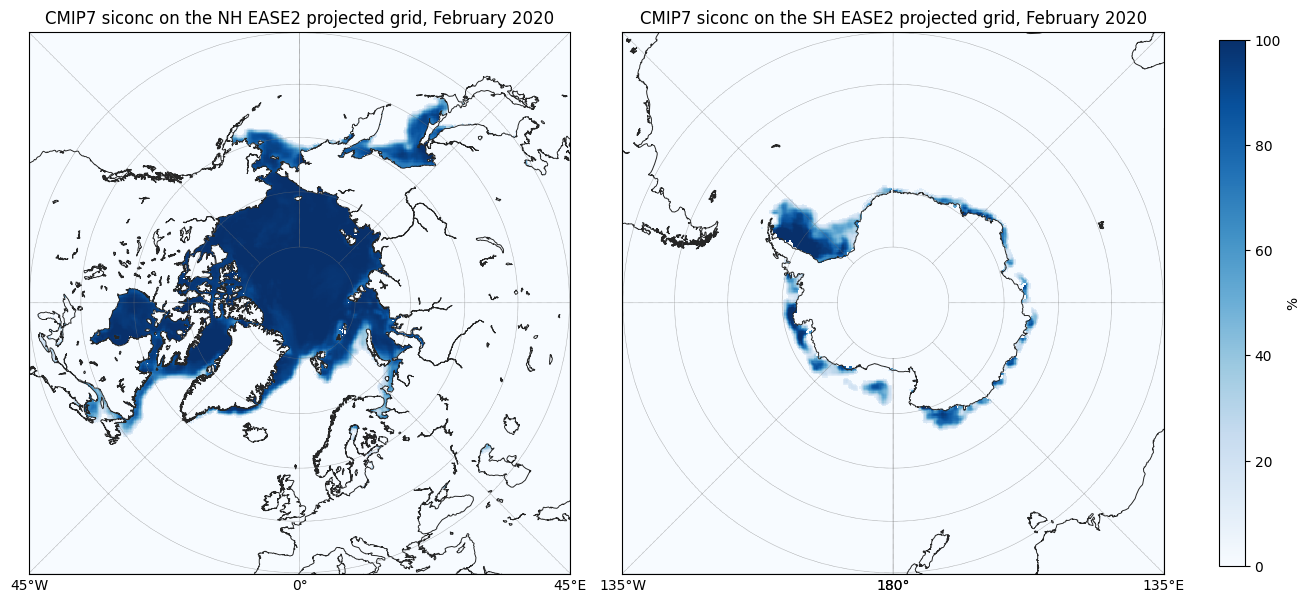

In [6]:
with xr.open_dataset(netcdf_paths["sh"], decode_times=False) as opened:
    south_ds = opened.load()


def plot_polar_siconc(ax, dataset, hemisphere):
    is_north = hemisphere == "nh"
    map_plot = Basemap(
        projection="laea",
        lat_0=90 if is_north else -90,
        lon_0=0,
        width=10_800_000,
        height=10_800_000,
        resolution="l",
        ax=ax,
    )
    map_plot.drawmapboundary(fill_color="#f7fbff", linewidth=0.8)
    map_plot.fillcontinents(color="0.82", lake_color="#f7fbff", zorder=0)
    longitude_plot = dataset["longitude"].values.T
    latitude_plot = dataset["latitude"].values.T
    field = dataset["siconc"].isel(time=0).values.T
    x_plot, y_plot = map_plot(longitude_plot, latitude_plot)
    mesh = map_plot.pcolormesh(x_plot, y_plot, field, shading="auto", cmap="Blues", vmin=0, vmax=100)
    map_plot.drawcoastlines(linewidth=0.7, color="0.15")
    parallels = np.arange(40, 91, 10) if is_north else np.arange(-80, -39, 10)
    map_plot.drawparallels(parallels, labels=[1, 0, 0, 0], linewidth=0.4, color="0.45", dashes=[1, 1])
    map_plot.drawmeridians(np.arange(-180, 181, 45), labels=[0, 0, 0, 1], linewidth=0.4, color="0.45", dashes=[1, 1])
    ax.set_title(f"CMIP7 siconc on the {hemisphere.upper()} EASE2 projected grid, February 2020")
    return mesh


fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), constrained_layout=True)
mesh = plot_polar_siconc(axes[0], ds, "nh")
plot_polar_siconc(axes[1], south_ds, "sh")
colorbar = fig.colorbar(mesh, ax=axes, location="right", shrink=0.82, pad=0.03)
colorbar.set_label("%")
plt.show()